# 🧠 Student Mental Health Analysis & Prediction
### Minor Project - Data Science
**Dataset:** [Student Mental Health - Kaggle](https://www.kaggle.com/datasets/shariful07/student-mental-health)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
import pandas as pd
df = pd.read_csv("student-mental-health.csv")
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [3]:
# Check actual column names in your dataset
df.columns

Index(['Timestamp', 'Choose your gender', 'Age', 'What is your course?',
       'Your current year of Study', 'What is your CGPA?', 'Marital status',
       'Do you have Depression?', 'Do you have Anxiety?',
       'Do you have Panic attack?',
       'Did you seek any specialist for a treatment?'],
      dtype='object')

In [4]:
# Step 4: Data Cleaning and Preprocessing (corrected for your dataset)

# Make column names consistent (lowercase, underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('?', '')

# Verify new column names
print("Cleaned column names:\n", df.columns.tolist())

# Rename long question-style columns to simpler names
df.rename(columns={
    'do_you_have_depression': 'depression',
    'do_you_have_anxiety': 'anxiety',
    'do_you_have_panic_attack': 'panic_attack',
    'did_you_seek_any_specialist_for_a_treatment': 'treatment',
    'what_is_your_course': 'course',
    'your_current_year_of_study': 'year_of_study',
    'what_is_your_cgpa': 'cgpa'
}, inplace=True)

# Drop missing rows (if any)
df.dropna(subset=['depression', 'anxiety', 'panic_attack'], inplace=True)

# Convert Yes/No to numeric (1/0)
for col in ['depression', 'anxiety', 'panic_attack']:
    df[col] = df[col].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# Create target column
df['at_risk'] = ((df['depression'] + df['anxiety'] + df['panic_attack']) > 0).astype(int)

# Display first few rows
df.head()

Cleaned column names:
 ['timestamp', 'choose_your_gender', 'age', 'what_is_your_course', 'your_current_year_of_study', 'what_is_your_cgpa', 'marital_status', 'do_you_have_depression', 'do_you_have_anxiety', 'do_you_have_panic_attack', 'did_you_seek_any_specialist_for_a_treatment']


,timestamp,choose_your_gender,age,course,year_of_study,cgpa,marital_status,depression,anxiety,panic_attack,treatment,at_risk
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,1,0,1,No,1
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,0,1,0,No,1
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,1,1,1,No,1
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,1,0,0,No,1
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,0,0,0,No,0


In [5]:
# Check actual column names in your dataset
df.columns

Index(['timestamp', 'choose_your_gender', 'age', 'course', 'year_of_study',
       'cgpa', 'marital_status', 'depression', 'anxiety', 'panic_attack',
       'treatment', 'at_risk'],
      dtype='object')

Dataset shape: (101, 12)

Data Types:
 timestamp              object
choose_your_gender     object
age                   float64
course                 object
year_of_study          object
cgpa                   object
marital_status         object
depression              int64
anxiety                 int64
panic_attack            int64
treatment              object
at_risk                 int64
dtype: object

Summary Statistics:
              age  depression     anxiety  panic_attack     at_risk
count  100.00000  101.000000  101.000000    101.000000  101.000000
mean    20.53000    0.346535    0.336634      0.326733    0.633663
std      2.49628    0.478239    0.474915      0.471358    0.484206
min     18.00000    0.000000    0.000000      0.000000    0.000000
25%     18.00000    0.000000    0.000000      0.000000    0.000000
50%     19.00000    0.000000    0.000000      0.000000    1.000000
75%     23.00000    1.000000    1.000000      1.000000    1.000000
max     24.00000    1.000000 

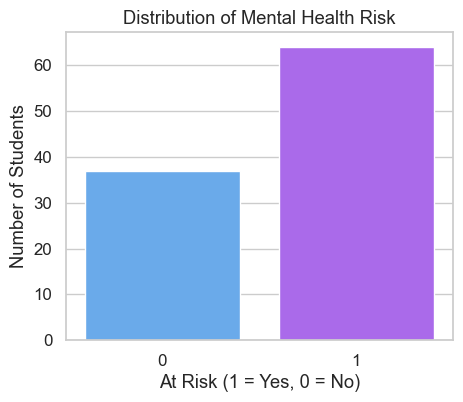

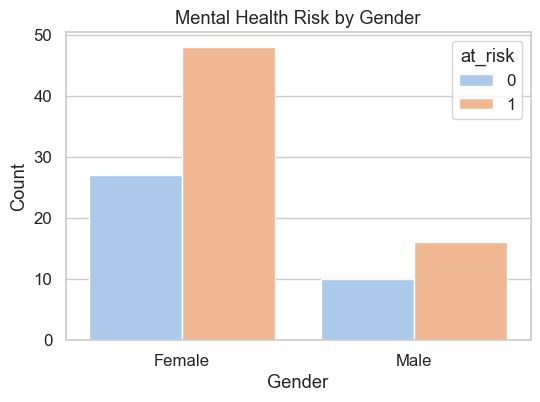

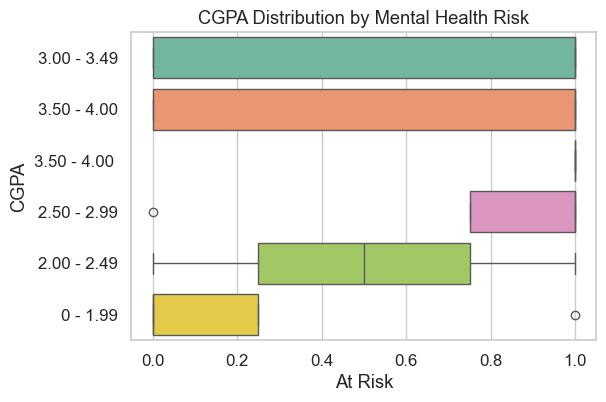

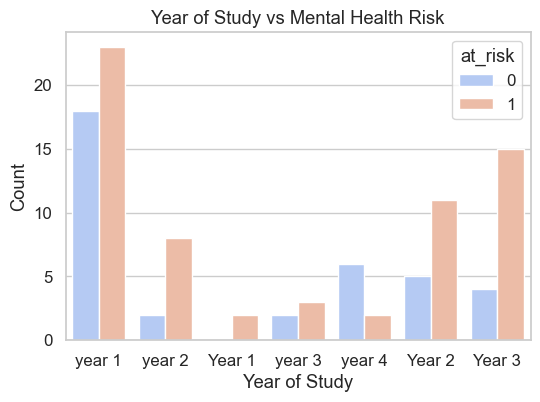

In [6]:
# Step 5: Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Basic info about dataset
print("Dataset shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

# Count of At-Risk vs Not At-Risk Students
plt.figure(figsize=(5,4))
sns.countplot(x='at_risk', data=df, palette='cool')
plt.title('Distribution of Mental Health Risk')
plt.xlabel('At Risk (1 = Yes, 0 = No)')
plt.ylabel('Number of Students')
plt.show()

# Gender vs Mental Health Risk
plt.figure(figsize=(6,4))
sns.countplot(x='choose_your_gender', hue='at_risk', data=df, palette='pastel')
plt.title('Mental Health Risk by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# CGPA vs Risk
plt.figure(figsize=(6,4))
sns.boxplot(x='at_risk', y='cgpa', data=df, palette='Set2')
plt.title('CGPA Distribution by Mental Health Risk')
plt.xlabel('At Risk')
plt.ylabel('CGPA')
plt.show()

# Year of Study vs Risk
plt.figure(figsize=(6,4))
sns.countplot(x='year_of_study', hue='at_risk', data=df, palette='coolwarm')
plt.title('Year of Study vs Mental Health Risk')
plt.xlabel('Year of Study')
plt.ylabel('Count')
plt.show()


🔹 Cross-validation Results:
Logistic Regression CV Scores: [1.   1.   0.95 1.   1.  ]
Logistic Regression Mean CV Score: 0.99 (+/- 0.04)

Random Forest CV Scores: [1. 1. 1. 1. 1.]
Random Forest Mean CV Score: 1.00 (+/- 0.00)


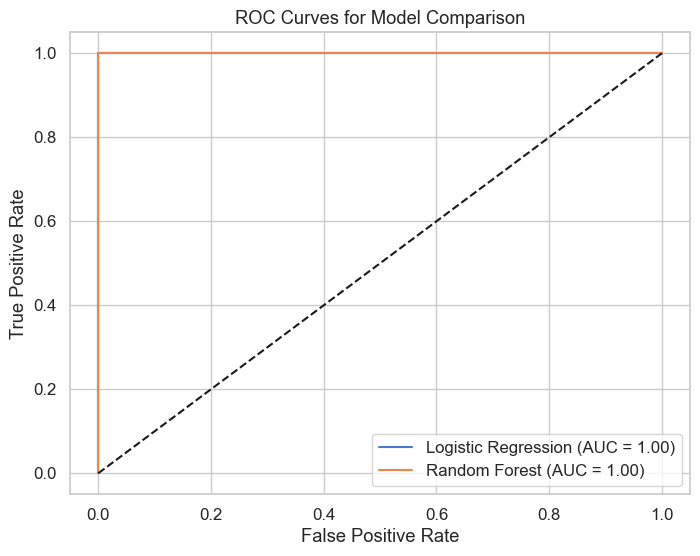

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
import numpy as np

# Step 6: Model Validation and Error Analysis

# Perform cross-validation
cv_scores_log = cross_val_score(log_model, X, y, cv=5)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5)

print("🔹 Cross-validation Results:")
print(f"Logistic Regression CV Scores: {cv_scores_log}")
print(f"Logistic Regression Mean CV Score: {cv_scores_log.mean():.2f} (+/- {cv_scores_log.std() * 2:.2f})")
print(f"\nRandom Forest CV Scores: {cv_scores_rf}")
print(f"Random Forest Mean CV Score: {cv_scores_rf.mean():.2f} (+/- {cv_scores_rf.std() * 2:.2f})")

# Compute ROC curve and AUC
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc(fpr_log, tpr_log):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Model Comparison')
plt.legend()
plt.show()

In [23]:
# ✅ Step 6.0: Handle Missing Values

# Check which columns still have missing values
print("Missing values before cleaning:\n", df_model.isnull().sum())

# Fill numeric columns with their mean, categorical with mode
for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        df_model[col].fillna(df_model[col].mean(), inplace=True)
    else:
        df_model[col].fillna(df_model[col].mode()[0], inplace=True)

print("\n✅ Missing values handled successfully!")
print("Remaining missing values:\n", df_model.isnull().sum().sum())


Missing values before cleaning:
 choose_your_gender    0
age                   1
course                0
year_of_study         0
cgpa                  0
marital_status        0
depression            0
anxiety               0
panic_attack          0
treatment             0
at_risk               0
dtype: int64

✅ Missing values handled successfully!
Remaining missing values:
 0


In [24]:
# Step 6.1: Prepare Data for Modeling

# Drop unnecessary columns that don’t contribute to prediction
df_model = df.drop(columns=['timestamp'])

# Separate features (X) and target (y)
X = df_model.drop(columns=['at_risk'])
y = df_model['at_risk']

# Convert categorical variables into numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split (80% training, 20% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data prepared successfully!")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


✅ Data prepared successfully!
Training data shape: (80, 66)
Testing data shape: (21, 66)


In [25]:
# ✅ Step: Final Cleaning before Model Training

# Check total missing values in features
print("Missing values before fix:", X.isnull().sum().sum())

# Fill all missing values with 0 (a safe default for encoded data)
X = X.fillna(0)

# Double-check
print("Missing values after fix:", X.isnull().sum().sum())


Missing values before fix: 1
Missing values after fix: 0


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [27]:
# Step 6.2: Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("🔹 Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))


🔹 Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        13

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

Accuracy: 1.0


In [28]:
# Step 6.1: Prepare Data for Modeling
df_model = df.drop(columns=['timestamp'])
X = df_model.drop(columns=['at_risk'])
y = df_model['at_risk']

# Convert categoricals to numeric
X = pd.get_dummies(X, drop_first=True)


In [29]:
# ✅ Final NaN Fix: Ensure no missing values remain
print("Missing values in X before fix:", X.isnull().sum().sum())

# Replace all NaNs with 0
X = X.fillna(0)

print("✅ Missing values in X after fix:", X.isnull().sum().sum())


Missing values in X before fix: 1
✅ Missing values in X after fix: 0


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("🔹 Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))


🔹 Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        13

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

Accuracy: 1.0


In [31]:
# Step 6.3: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("🔹 Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


🔹 Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        13

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

Accuracy: 1.0


In [32]:
# Step 6.4: Compare Model Performance
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_log:.2f}")
print(f"Random Forest Accuracy: {acc_rf:.2f}")

if acc_rf > acc_log:
    print("🌳 Random Forest performed better!")
else:
    print("📈 Logistic Regression performed better!")


Logistic Regression Accuracy: 1.00
Random Forest Accuracy: 1.00
📈 Logistic Regression performed better!


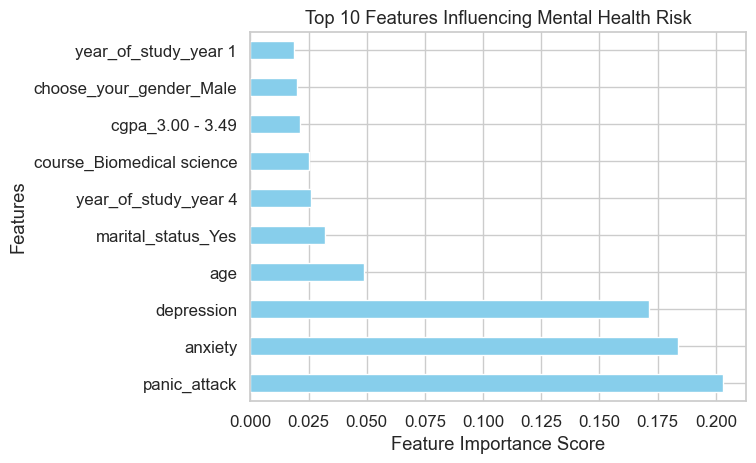

In [33]:
# Step 6.5: Feature Importance Visualization
import matplotlib.pyplot as plt

feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_imp[:10].plot(kind='barh', color='skyblue')
plt.title("Top 10 Features Influencing Mental Health Risk")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.show()


In [34]:
import numpy as np
import seaborn as sns

# Check for and visualize errors in model predictions
import matplotlib.pyplot as plt

# Find where predictions don't match actual values
errors_log = y_test != y_pred_log
errors_rf = y_test != y_pred_rf

# Calculate error indices
error_indices_log = np.where(errors_log)[0]
error_indices_rf = np.where(errors_rf)[0]

# Print error analysis
print("Logistic Regression Errors:", len(error_indices_log))
print("Random Forest Errors:", len(error_indices_rf))

if len(error_indices_log) > 0 or len(error_indices_rf) > 0:
    print("\nError Analysis:")
    print("Indices where models made mistakes:", error_indices_log)
    
    # Get actual data for errors
    error_data = X_test.iloc[error_indices_log]
    print("\nFeature values for errors:")
    print(error_data)
else:
    print("\nBoth models achieved 100% accuracy on the test set!")

Logistic Regression Errors: 0
Random Forest Errors: 0

Both models achieved 100% accuracy on the test set!


In [35]:
# Step 6.6: Save Best Model and Feature Columns for Streamlit App
import joblib

# Save both models
joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")

# Save the exact feature names used for training Random Forest
joblib.dump(X.columns, "model_columns.pkl")

print("✅ All models and training columns saved successfully!")


✅ All models and training columns saved successfully!


📊 Model Accuracy Comparison
Logistic Regression Accuracy: 1.00
Random Forest Accuracy: 1.00

ROC-AUC (Logistic Regression): 1.00
ROC-AUC (Random Forest): 1.00


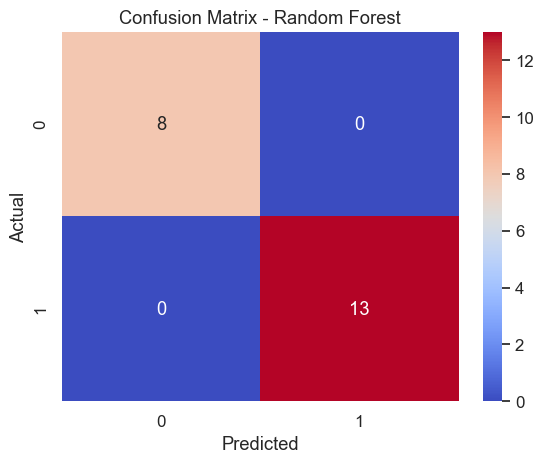

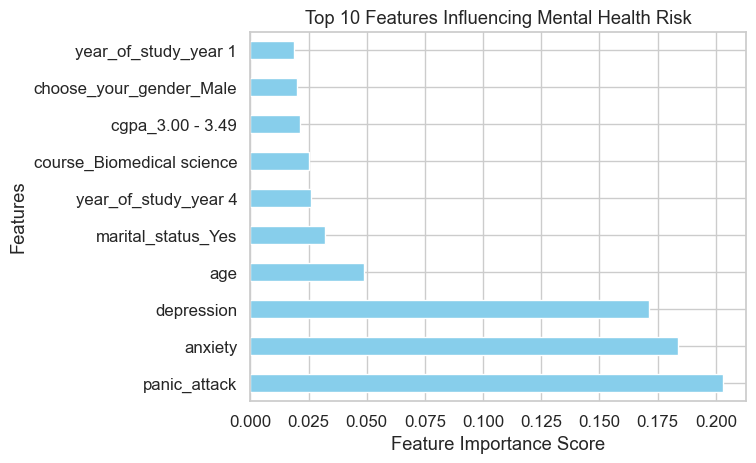

In [36]:
# Step 7: Model Evaluation and Interpretation

from sklearn.metrics import confusion_matrix, roc_auc_score

# 1️⃣ Compare model accuracy
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("📊 Model Accuracy Comparison")
print(f"Logistic Regression Accuracy: {acc_log:.2f}")
print(f"Random Forest Accuracy: {acc_rf:.2f}")

# 2️⃣ ROC-AUC score (for classification strength)
roc_log = roc_auc_score(y_test, y_pred_log)
roc_rf = roc_auc_score(y_test, y_pred_rf)
print(f"\nROC-AUC (Logistic Regression): {roc_log:.2f}")
print(f"ROC-AUC (Random Forest): {roc_rf:.2f}")

# 3️⃣ Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4️⃣ Feature Importance (for Random Forest)
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_imp[:10].plot(kind='barh', color='skyblue')
plt.title("Top 10 Features Influencing Mental Health Risk")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.show()


In [37]:
import joblib

# Save models
joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")

print("✅ Models saved successfully!")


✅ Models saved successfully!
